In [ ]:
# LangChain → for building simple AI pipelines
# LangGraph → for building complex, stateful AI workflows

| Feature  | LangChain   | LangGraph              |
| -------- | ----------- | ---------------------- |
| Flow     | Linear      | Graph (multiple paths) |
| Memory   | Limited     | Strong state handling  |
| Loops    | Hard        | Easy                   |
| Control  | Basic       | Advanced               |
| Use case | Simple apps | Complex agents         |


In [1]:
# 1. Simple chatbot → LangChain
# User → LLM → Answer
# No complexity → use LangChain

# 2. Customer support AI → LangGraph
# User → Understand intent
#       → If billing → billing agent
#       → If tech issue → tech agent
#       → If unclear → ask again
#       → Retry if failed
# Needs branching + logic → LangGraph

# 3. AI Research Agent
# Search → Read → Summarize → Check quality
#        → If bad → search again (loop)
# Loop + decision → LangGraph

# 4. Multi-step automation
# Example:
# Read email
# Decide priority
# Draft reply
# Ask for approval
# Send
# Not linear → needs graph structure → LangGraph

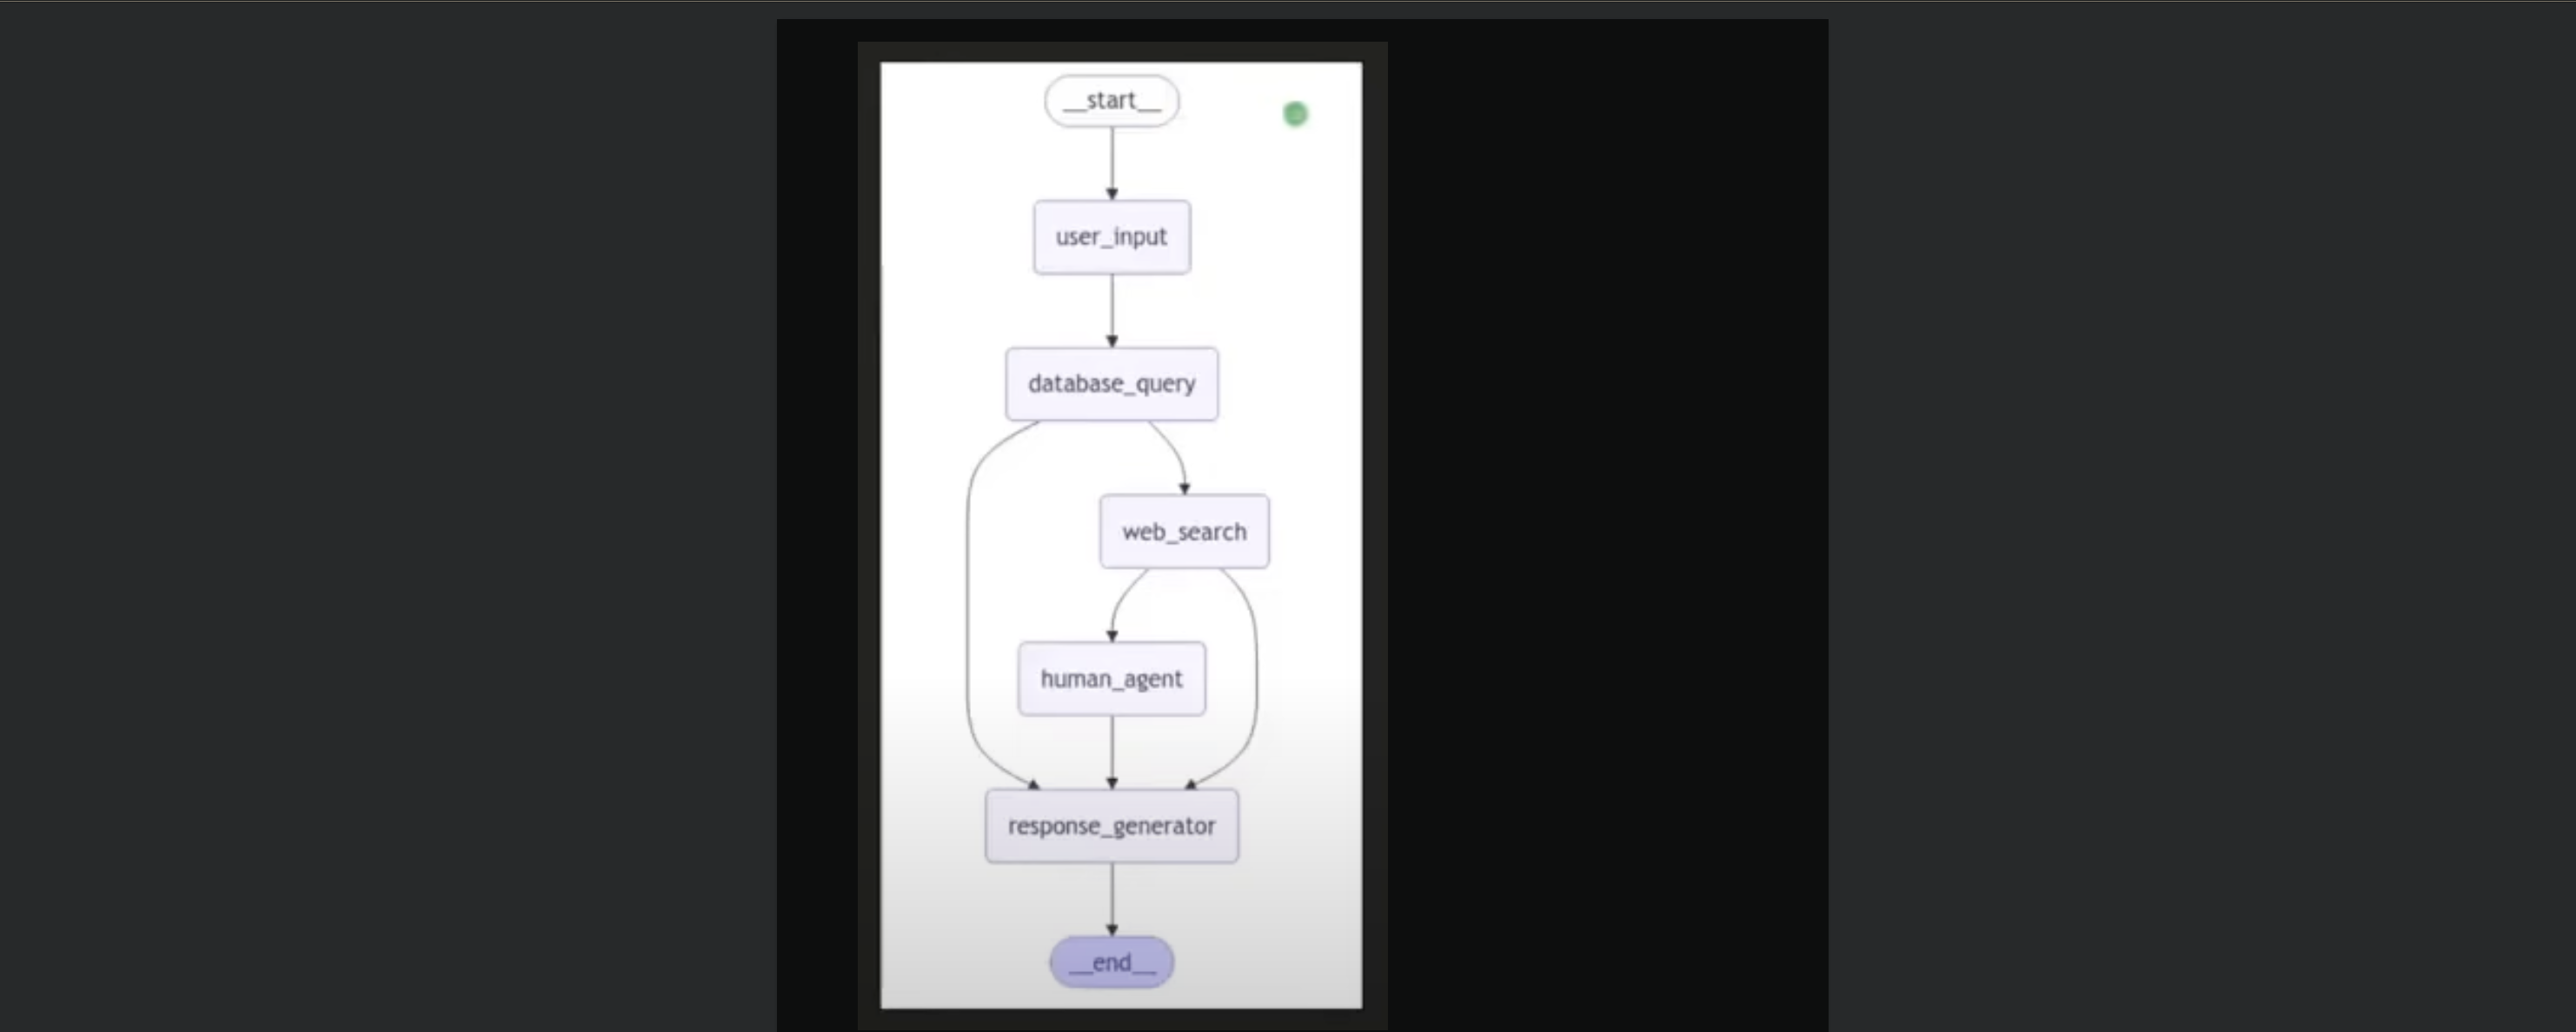

---

# LangGraph Chatbot System Explained with State Evolution

The internal working of a chatbot built using **LangGraph**, structured around:

1. **Node**
2. **Edge**
3. **State**
4. **State Machine**
5. **State Evolution: Step-by-Step Message Trail**

---

## 1. Node – The Functional Unit

A **node** is a logical step or processing unit in a LangGraph system. Each node takes the current `state`, performs a task (e.g., querying a DB, running a tool), and returns an updated state.

### Real Nodes in the Chatbot Graph:

| Node Name            | Purpose                                                         |
| -------------------- | --------------------------------------------------------------- |
| `user_input`         | Captures and stores the user's initial query                    |
| `database_query`     | Checks internal knowledge (e.g., vector store, database, rules) |
| `web_search`         | Queries an external source if the database fails                |
| `human_agent`        | Escalates when automation is insufficient                       |
| `response_generator` | Creates the final response to return to the user                |

---

## 2. Edge – The Transition Between Nodes

An **edge** defines the **flow from one node to another**. These can be unconditional (fixed path) or conditional (based on logic in the state).

### Example:

* From `database_query` to:

  * `response_generator` if data found
  * `web_search` if not found

This allows building intelligent, decision-based flows.

---

## 3. State – The Shared Memory

The **state** is a dictionary that holds everything we know so far in the chat. It gets passed through every node, and each node can update or enrich it.

### Format:

```python
state = {
    "messages": [
        {"role": "user", "content": "What is quantum computing?"}
    ]
}
```

The `messages` list grows as each node appends its contribution.

---

## 4. State Machine – The Orchestration Engine

LangGraph builds a **state machine** by connecting nodes through edges, managing:

* Start and end points
* Which node runs next
* How state is passed and updated

Think of this as the "brain" of the chatbot.

---

## 5. State Evolution – Message-by-Message Trace

**How exactly does state evolves**, using the connected messages:

---

### Step 1: Initial State from `user_input`

```python
state = {
    "messages": [
        {"role": "user", "content": "Hello, What is quantum computing?"}
    ]
}
```

**Explanation**:
The user types a question. This is the only entry in the state so far. It will be used by downstream nodes.

---

### Step 2: Updated State by `database_query`

```python
state = {
    "messages": [
        {"role": "user", "content": "Hello, What is quantum computing?"},
        {"role": "db_query_tool", "content": "Hi, I am not sure about the answer. Use web search."}
    ]
}
```

**Explanation**:
The `database_query` node checks its internal source and **does not find a match**.
Instead of answering, it **suggests using the web search**, and appends its response to the state.

---

### Step 3: Updated State by `web_search`

```python
state = {
    "messages": [
        {"role": "user", "content": "Hello, What is quantum computing?"},
        {"role": "db_query_tool", "content": "Hi, I am not sure about the answer. Use web search."},
        {"role": "web_search", "content": "Quantum computing is a type of computing that uses quantum mechanics principles to process information."}
    ]
}
```

**Explanation**:
The `web_search` node is triggered next. It calls a real-time tool (e.g., DuckDuckGo or Wikipedia API), and **retrieves the actual answer**.
That answer is **appended** to the `messages` list.

---

### Optional Step: Appending Human-Agent Review

```python
state["messages"].append({
    "role": "human_agent",
    "content": "Verified. This explanation is correct and safe to show to user."
})
```

**Explanation**:
In safety-critical domains (e.g., medical or legal), this step allows a human to review.
The `human_agent` node simulates such oversight, and its confirmation is **added to the state**.

---

### Final Step: Generated Response by `response_generator`

```python
def response_generator(state):
    combined = "\n".join([msg["content"] for msg in state["messages"]])
    final = f"Here is the final answer:\n{combined}"
    state["messages"].append({"role": "assistant", "content": final})
    return {"messages": state["messages"]}
```

**Explanation**:
The final node aggregates all prior responses into a coherent final message that is stored in the state and returned to the user.

---

## Summary Table: How the State Builds Up

| Step       | Role                 | New Entry Added to State                                        |
| ---------- | -------------------- | --------------------------------------------------------------- |
| Step 1     | `user_input`         | {"role": "user", "content": "..."}                              |
| Step 2     | `database_query`     | {"role": "db\_query\_tool", "content": "..."}                   |
| Step 3     | `web_search`         | {"role": "web\_search", "content": "..."}                       |
| Optional   | `human_agent`        | {"role": "human\_agent", "content": "..."}                      |
| Final Step | `response_generator` | {"role": "assistant", "content": "Here is the final answer..."} |

---

## Conclusion

By the end of the workflow:

* The **state contains the complete audit trail**
* Every node has **one job** and updates the state **immutably**
* You can visualize this state growth to debug, audit, or train models

---